In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Illustrative collinear H + H2 -> H2 + H exchange PES
# Coordinates:
#   x1 = H-H distance between atoms 1 and 2
#   x2 = H-H distance between atoms 2 and 3
#
# This is a smooth model surface designed to reproduce the
# qualitative topology of the H3 exchange reaction:
# two H2 + H valleys connected through an exchange region.
# It is not a high-accuracy ab initio H3 potential.
# ------------------------------------------------------------

# Approximate H2 Morse parameters
De = 4.75      # eV
re = 0.741     # Angstrom
a = 1.95       # Angstrom^-1

def morse(r):
    """Morse potential with minimum -De and dissociation limit 0."""
    return De * (1.0 - np.exp(-a * (r - re)))**2 - De


# Three-body barrier/repulsion parameters
beta = 2.6
rc = 0.93
sigma_parallel = 0.28
sigma_diag = 0.22


def total_potential_raw(x1, x2):
    """Vectorized, unshifted collinear H3 exchange PES.

    x1, x2 : array_like (any broadcastable shape, including scalars)
    Returns an array of the same broadcast shape.
    """
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)

    V12 = morse(x1)
    V23 = morse(x2)

    # For a collinear H-H-H geometry: r13 = x1 + x2
    r13 = x1 + x2
    V13 = morse(r13)

    # Smooth bond-switching term: approaches V12/V23 in each channel
    Vswitch = -np.log(
        np.exp(-beta * V12)
        + np.exp(-beta * V23)
    ) / beta

    # Three-body exchange barrier
    barrier = 0.78 * np.exp(
        -((x1 + x2 - 2.0 * rc)**2)
        / (2.0 * sigma_parallel**2)

        -((x1 - x2)**2)
        / (2.0 * sigma_diag**2)
    )

    # Strong repulsion when all three H atoms become compressed
    repulsion = 2.5 * np.exp(
        -5.0 * (x1 + x2 - 1.25)
    )

    # Small contribution from the outer H-H interaction
    three_body = 0.12 * np.maximum(
        V13 + De,
        0.0
    )

    return Vswitch + barrier + repulsion + three_body


# Reference grid used to determine the zero-of-energy offset
_x1_ref = np.linspace(0.55, 3.2, 260)
_x2_ref = np.linspace(0.55, 3.2, 260)
_X1_ref, _X2_ref = np.meshgrid(_x1_ref, _x2_ref)
V_MIN = np.min(total_potential_raw(_X1_ref, _X2_ref))


def total_potential(x1, x2, clip=(0.0, 5.0)):
    """Vectorized total potential, shifted so the minimum is zero.

    x1, x2 : array_like (any broadcastable shape, including scalars)
    clip : optional (low, high) tuple to clamp the displayed energies,
        or None to leave the raw shifted values unclipped.
    """
    V = total_potential_raw(x1, x2) - V_MIN
    if clip is not None:
        V = np.clip(V, clip[0], clip[1])
    return V


# Coordinate grid
x1 = np.linspace(0.55, 3.2, 260)
x2 = np.linspace(0.55, 3.2, 260)

X1, X2 = np.meshgrid(x1, x2)

V = total_potential(X1, X2)



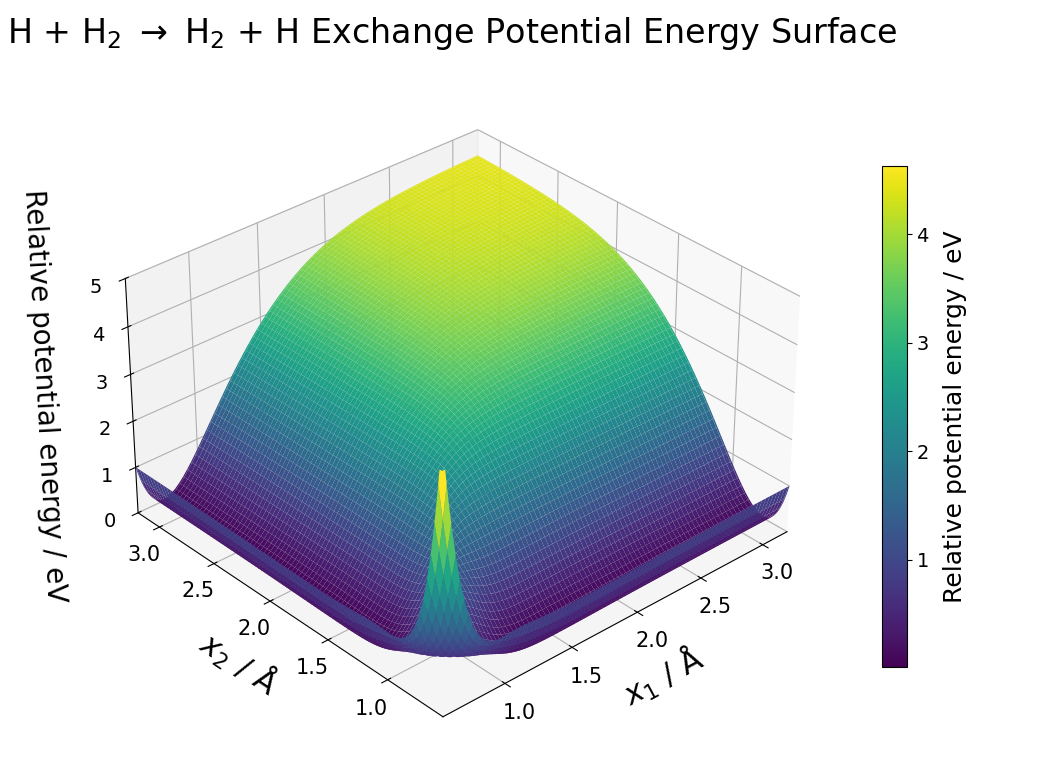

In [18]:

# ============================================================
# 3D SURFACE PLOT
# ============================================================

fig = plt.figure(figsize=(10.5, 7.8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

surf = ax.plot_surface(
    X1,
    X2,
    V,
    cmap="viridis",
    rstride=3,
    cstride=3,
    linewidth=0,
    antialiased=True
)


# Axis labels
ax.set_xlabel(
    r"$x_1$ / Å",
    fontsize=22,
    labelpad=12
)

ax.set_ylabel(
    r"$x_2$ / Å",
    fontsize=22,
    labelpad=12
)

ax.set_zlabel(
    "Relative potential energy / eV",
    fontsize=20,
    labelpad=14
)


# Title
ax.set_title(
    r"H + H$_2$ $\rightarrow$ H$_2$ + H "
    r"Exchange Potential Energy Surface",
    fontsize=24,
    pad=18
)


# Tick sizes
ax.tick_params(
    axis="x",
    labelsize=15
)

ax.tick_params(
    axis="y",
    labelsize=15
)

ax.tick_params(
    axis="z",
    labelsize=14
)


# Plot limits
ax.set_xlim(0.55, 3.2)
ax.set_ylim(0.55, 3.2)
ax.set_zlim(0.0, 5.0)


# Shape of the 3D plotting box
ax.set_box_aspect(
    (1.1, 1.1, 0.65)
)


# Camera angle
ax.view_init(
    elev=32,
    azim=-132
)


# Color bar
cbar = fig.colorbar(
    surf,
    ax=ax,
    shrink=0.72,
    pad=0.08
)

cbar.set_label(
    "Relative potential energy / eV",
    fontsize=18,
    labelpad=10
)

cbar.ax.tick_params(
    labelsize=14
)


plt.tight_layout()
plt.show()

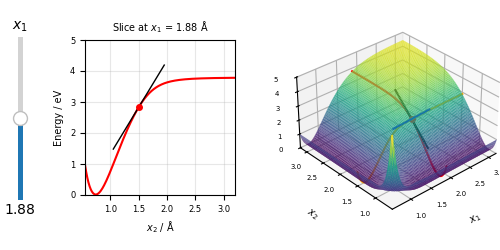

In [23]:
# Requires an interactive backend (e.g. `pip install ipympl`) for live updates
%matplotlib widget
from matplotlib.widgets import Slider

fig = plt.figure(figsize=(5, 2.5))

# Hide the ipympl toolbar/header so it doesn't interfere with the layout
fig.canvas.toolbar_visible = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.resizable = False

# Vertical slider, placed to the left of both plots
ax_slider = fig.add_axes([0.03, 0.2, 0.02, 0.65])

# Left: slice through the surface at constant x1 (leave room for the y-label)
ax_slice = fig.add_axes([0.17, 0.22, 0.30, 0.62])

# Right: full 3D surface (narrower/inset to leave room for its own padding)
ax_surf = fig.add_subplot(1, 2, 2, projection="3d")
ax_surf.set_position([0.58, 0.05, 0.42, 0.95])

x1_init = x1[len(x1) // 2]

slider = Slider(
    ax=ax_slider,
    label=r"$x_1$",
    valmin=float(x1.min()),
    valmax=float(x1.max()),
    valinit=x1_init,
    orientation="vertical",
)
ax_slider.tick_params(labelsize=6)
ax_slider.xaxis.label.set_size(7)

# Static surface
ax_surf.plot_surface(
    X1, X2, V,
    cmap="viridis",
    rstride=3,
    cstride=3,
    linewidth=0,
    antialiased=True,
    alpha=0.85,
)
ax_surf.set_xlabel(r"$x_1$", fontsize=7, labelpad=2)
ax_surf.set_ylabel(r"$x_2$", fontsize=7, labelpad=2)
#ax_surf.set_zlabel("Energy / eV", fontsize=13, labelpad=10)
ax_surf.set_xlim(0.55, 3.2)
ax_surf.set_ylim(0.55, 3.2)
ax_surf.set_zlim(0.0, 5.0)
ax_surf.set_box_aspect((1.1, 1.1, 0.65))
ax_surf.view_init(elev=32, azim=-132)
ax_surf.tick_params(labelsize=5, pad=0)

# Red curve on the surface marking the current x1 slice
Vslice_init = total_potential(np.full_like(x2, x1_init), x2)
slice_marker, = ax_surf.plot(
    np.full_like(x2, x1_init), x2, Vslice_init,
    color="red", linewidth=1.5,
)

# 2D plot of the slice
line_slice, = ax_slice.plot(x2, Vslice_init, color="red")
ax_slice.set_xlabel(r"$x_2$ / Å", fontsize=7)
ax_slice.set_ylabel("Energy / eV", fontsize=7)
ax_slice.set_xlim(x2.min(), x2.max())
ax_slice.set_ylim(0.0, 5.0)
ax_slice.set_title(rf"Slice at $x_1$ = {x1_init:.2f} Å", fontsize=7)
ax_slice.tick_params(labelsize=6)
ax_slice.grid(True, alpha=0.3)


# Derivative overlay options
show_derivative = True
x20 = 1.5
_h = 1.0e-3  # finite-difference step for d(total_potential)/dx2

# Static trace of the slice along x1 (at fixed x2 = x20) on the 3D surface;
# also gates whether the dV/dx1 tangent line is shown
show_x1_slice = True

if show_x1_slice:
    Vslice_x1 = total_potential(x1, np.full_like(x1, x20))
    x1_slice_trace, = ax_surf.plot(
        x1, np.full_like(x1, x20), Vslice_x1,
        color="orange", linewidth=1.5,
    )


def dV_dx2(x1_val, x20_val, h=_h):
    """Centered finite-difference estimate of dV/dx2 at (x1_val, x20_val)."""
    return (
        total_potential(x1_val, x20_val + h)
        - total_potential(x1_val, x20_val - h)
    ) / (2.0 * h)


def dV_dx1(x1_val, x20_val, h=_h):
    """Centered finite-difference estimate of dV/dx1 at (x1_val, x20_val)."""
    return (
        total_potential(x1_val + h, x20_val)
        - total_potential(x1_val - h, x20_val)
    ) / (2.0 * h)


if show_derivative:
    _tangent_half_width = 0.45
    x2_tangent = np.array([x20 - _tangent_half_width, x20 + _tangent_half_width])

    V20_init = total_potential(x1_init, x20)
    slope_init = dV_dx2(x1_init, x20)
    tangent_init = V20_init + slope_init * (x2_tangent - x20)

    # Tangent line and marker on the 2D slice
    tangent_line_2d, = ax_slice.plot(
        x2_tangent, tangent_init, color="black", linestyle="-", linewidth=1,
    )
    point_2d, = ax_slice.plot([x20], [V20_init], "o", color="red", markersize=4)

    # dV/dx2 tangent line on the 3D surface (fixed x1_init, varying x2)
    tangent_line_3d, = ax_surf.plot(
        np.full_like(x2_tangent, x1_init), x2_tangent, tangent_init,
        color="black", linestyle="-", linewidth=1.5,
    )
    point_3d, = ax_surf.plot(
        [x1_init], [x20], [V20_init], "o", color="red", markersize=4,
    )

    if show_x1_slice:
        x1_tangent_init = np.array(
            [x1_init - _tangent_half_width, x1_init + _tangent_half_width]
        )
        slope_x1_init = dV_dx1(x1_init, x20)
        tangent_x1_init = V20_init + slope_x1_init * (x1_tangent_init - x1_init)

        # dV/dx1 tangent line on the 3D surface (fixed x20, varying x1)
        tangent_line_3d_x1, = ax_surf.plot(
            x1_tangent_init, np.full_like(x1_tangent_init, x20), tangent_x1_init,
            color="blue", linestyle="-", linewidth=1.5,
        )


def update(x1_val):
    Vslice = total_potential(np.full_like(x2, x1_val), x2)
    line_slice.set_ydata(Vslice)
    ax_slice.set_title(rf"Slice at $x_1$ = {x1_val:.2f} Å", fontsize=7)
    slice_marker.set_data_3d(np.full_like(x2, x1_val), x2, Vslice)

    if show_derivative:
        V20 = total_potential(x1_val, x20)
        slope = dV_dx2(x1_val, x20)
        tangent = V20 + slope * (x2_tangent - x20)

        tangent_line_2d.set_data(x2_tangent, tangent)
        point_2d.set_data([x20], [V20])

        tangent_line_3d.set_data_3d(
            np.full_like(x2_tangent, x1_val), x2_tangent, tangent
        )
        point_3d.set_data_3d([x1_val], [x20], [V20])

        if show_x1_slice:
            x1_tangent = np.array(
                [x1_val - _tangent_half_width, x1_val + _tangent_half_width]
            )
            slope_x1 = dV_dx1(x1_val, x20)
            tangent_x1 = V20 + slope_x1 * (x1_tangent - x1_val)
            tangent_line_3d_x1.set_data_3d(
                x1_tangent, np.full_like(x1_tangent, x20), tangent_x1
            )

    fig.canvas.draw_idle()


slider.on_changed(update)

plt.show()